# Taller 3

### Autores: Harvey Benitez, Estefanía Laverde

In [97]:
!pip3 install scikit-image --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [115]:
from skimage.util import random_noise
from skimage.filters import threshold_local
from skimage.segmentation import flood
from skimage.segmentation import slic
from skimage import segmentation

from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# **1. Segmentación por umbralización**

### **1.1 Cree una nueva sección en su notebook**
### **1.2 Cargue la imagen de trabajo objects.png  y visualícela**

In [32]:
# guardar el path de las imagenes
images_path = 'images/'

# observamos las imagenes en el directorio
os.listdir(images_path)

['CHEST.png', 'OBJECTS.png', 'TEXT.png']

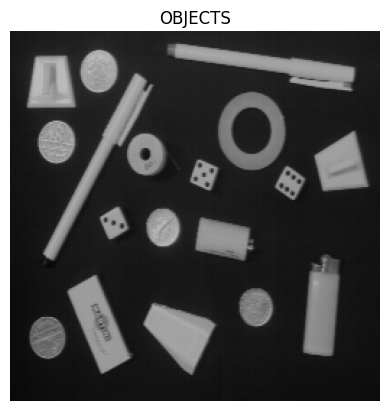

In [6]:
# lectura de la imagen
objects_image = cv2.imread(images_path + 'OBJECTS.png', cv2.IMREAD_GRAYSCALE)

# visualizar la imagen
plt.imshow(objects_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title('OBJECTS')
plt.show()


### **1.3 Visualice el histograma de la imagen de trabajo**

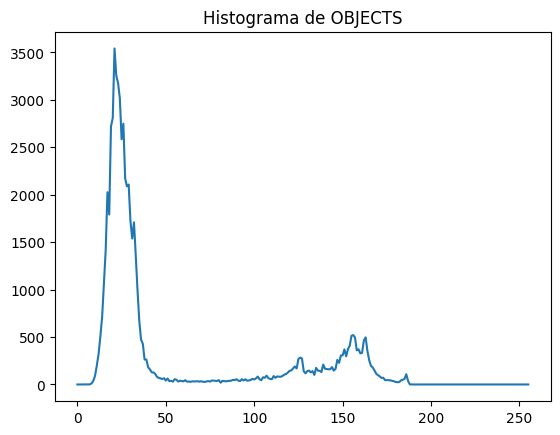

In [7]:
objects_hist = cv2.calcHist([objects_image], [0], None, [256], [0, 256])

plt.plot(objects_hist)
plt.title('Histograma de OBJECTS')
plt.show()

### **1.4 Aplique el algoritmo de umbralización global**

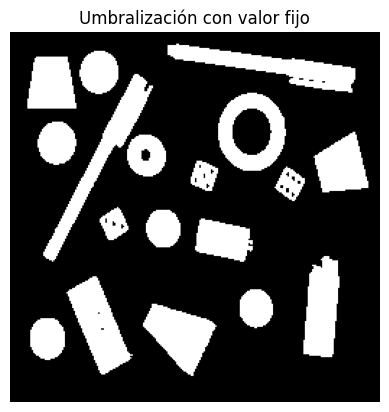

In [8]:
_, thres_image = cv2.threshold(objects_image, 65, 255, cv2.THRESH_BINARY)

plt.imshow(thres_image, cmap='gray')
plt.axis('off')
plt.title('Umbralización con valor fijo')
plt.show()

### **1.5 Aplique el algoritmo de umbralización de Otsu con un solo valor**

Valor de umbral para Otsu: 84.0


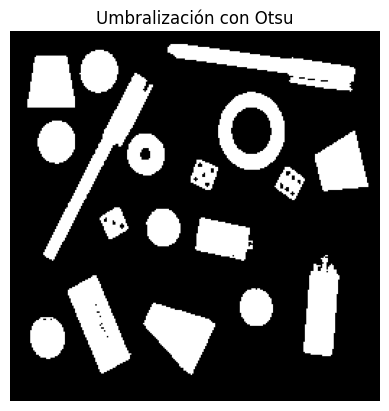

In [9]:
threshold, thres_image_otsu = cv2.threshold(objects_image, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
print(f"Valor de umbral para Otsu: {threshold}")

plt.imshow(thres_image_otsu, cmap='gray')
plt.axis('off')
plt.title('Umbralización con Otsu')
plt.show()

### **1.6 Ahora introduzca ruido gaussiano aditivo con varianza de 0.001 y luego con varianza de 0.05. Visualice el histograma de la imagen resultante. ¿Qué sucede? ¿Por qué sucede esto?**

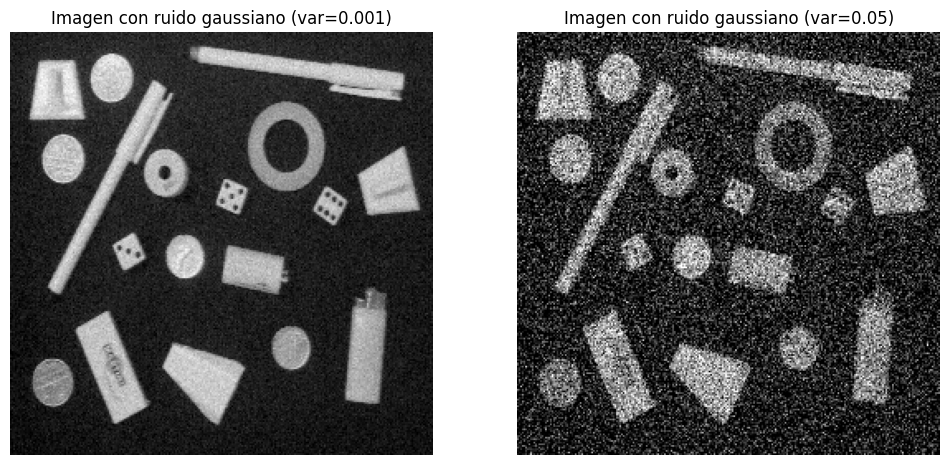

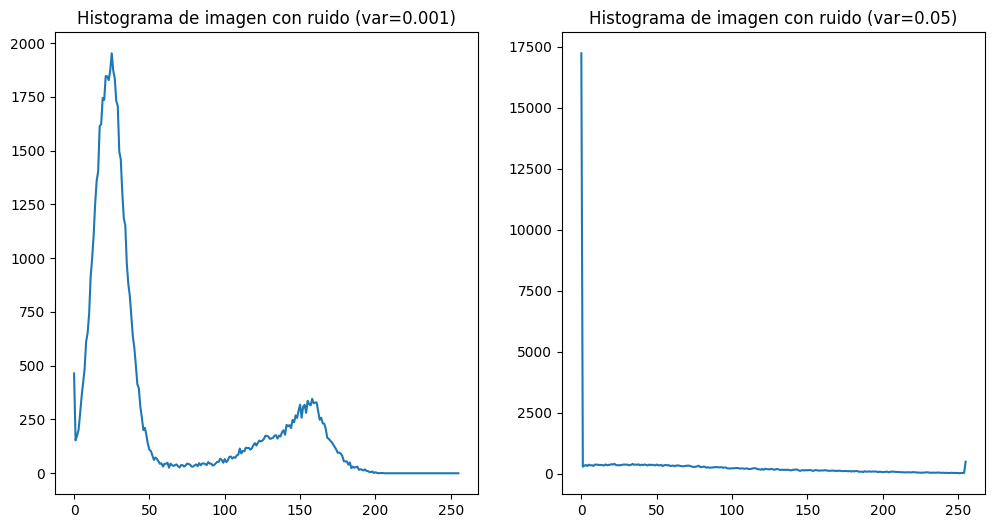

In [10]:
# introducir ruido gausiando 
noised_image_001 = random_noise(objects_image, mode='gaussian', mean=0,  var=0.001)
noised_image_05 = random_noise(objects_image, mode='gaussian', mean=0,  var=0.05)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(noised_image_001, cmap='gray')
plt.axis('off')
plt.title('Imagen con ruido gaussiano (var=0.001)')

plt.subplot(1, 2, 2)
plt.imshow(noised_image_05, cmap='gray')
plt.axis('off')
plt.title('Imagen con ruido gaussiano (var=0.05)')
plt.show()

# histogramas de las imágenes ruidosas

# convertir las imagenes ruidosas a 8 bits - la imagen original es continua de 0 a 1. Se multiplica por 255 y luego se pasa a 8bits
noised_001_uint8 = (noised_image_001 * 255).astype(np.uint8)
noised_05_uint8 = (noised_image_05 * 255).astype(np.uint8)

objects_hist_001 = cv2.calcHist([noised_001_uint8], [0], None, [256], [0, 256])
objects_hist_05 = cv2.calcHist([noised_05_uint8], [0], None, [256], [0, 256])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(objects_hist_001)
plt.title('Histograma de imagen con ruido (var=0.001)')

plt.subplot(1, 2, 2)
plt.plot(objects_hist_05)
plt.title('Histograma de imagen con ruido (var=0.05)')
plt.show()


Al introducir ruido gaussiano aditivo a la imagen, el valor de cada píxel se modifica mediante la suma de una variable aleatoria extraída de una Distribución Normal con media $\mu = 0$ y varianza $\sigma^2$ definida. En estas imágenes se percibe que al aumentar la varianza, el ruido aleatorio se aleja más de la media, tomando valores más extremos, lo que genera que la gran mayoría de ellos se saturen a los valores máximos y mínimos de la imagen, es decir, 0 y 255. 

En el histograma se ven reflejados estos efectos: la varianza de 0.001 mantiene el ruido cercano a la media (0), por lo que la distribución de la imagen original se mantiene con cierta dispersión, mientras que la varianza de 0.05 genera una gran cantidad de valores saturados, por lo que se ven dos picos principales, el mayor en torno a 0 y el otro en torno a 255.

### **1.7 Vuelva a correr las umbralizaciones sobre la imagen ¿Cómo afecta el ruido al resultado?**

Valor de umbral para Otsu (var=0.001): 84.0
Valor de umbral para Otsu (var=0.05): 84.0


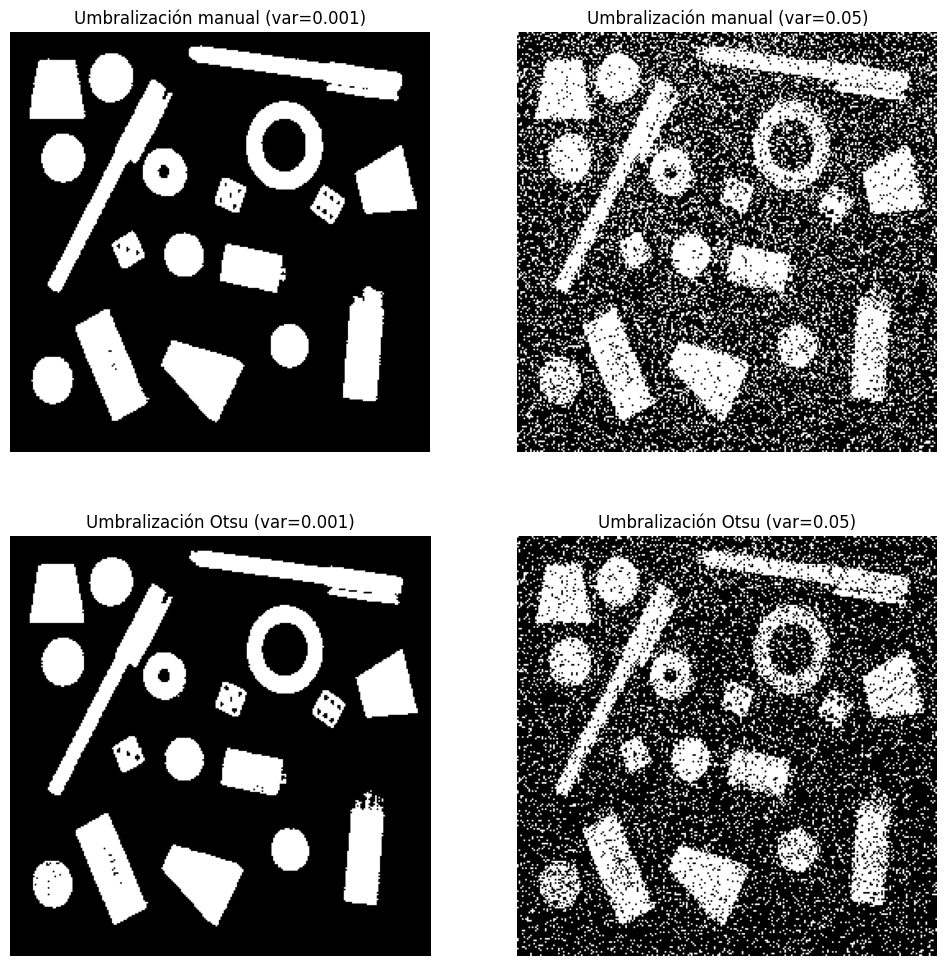

In [11]:
# umbralizaciones manuales con valor 65
_, thres_image_001 = cv2.threshold(noised_001_uint8, 65, 255, cv2.THRESH_BINARY)
_, thres_image_05 = cv2.threshold(noised_05_uint8, 65, 255, cv2.THRESH_BINARY)

# umbralizaciones con Otsu
threshold_001, thres_image_otsu_001 = cv2.threshold(noised_001_uint8, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
threshold_05, thres_image_otsu_05 = cv2.threshold(noised_05_uint8, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
print(f"Valor de umbral para Otsu (var=0.001): {threshold_001}")
print(f"Valor de umbral para Otsu (var=0.05): {threshold_05}")

# visualización de las imagenes resultantes

plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
plt.imshow(thres_image_001, cmap='gray')
plt.axis('off')
plt.title('Umbralización manual (var=0.001)')
plt.subplot(2, 2, 2)
plt.imshow(thres_image_05, cmap='gray')
plt.axis('off')
plt.title('Umbralización manual (var=0.05)')
plt.subplot(2, 2, 3)
plt.imshow(thres_image_otsu_001, cmap='gray')
plt.axis('off')
plt.title('Umbralización Otsu (var=0.001)')
plt.subplot(2, 2, 4)
plt.imshow(thres_image_otsu_05, cmap='gray')
plt.axis('off')
plt.title('Umbralización Otsu (var=0.05)')
plt.show()  



El ruido gaussiano aditivo degrada la eficacia de la umbralización a medida que aumenta la varianza. Con una varianza baja, el histograma de la imagen continúa siendo bimodal, lo que permite que tanto con el umbral manual como con aquel del método Otsu se logre una segmentación adecuada. Sin embargo, al incrementar la varianza a 0.05 el ruido genera una gran cantidad de valores saturados, lo que distorsiona el histograma creando nuevos picos en valores extremos y vuelve más difícil encontrar un umbral que separe de forma clara los objetos del fondo. Como resultado, en la imagen segmentada aparece mucho ruido similar al efecto de sal y pimienta, lo que demuestra que el algoritmo no pudo adaptarse a la nueva distribución de la imagen.

### **1.8 Cargue ahora la imagen de trabajo de text, visualícela y visualice su histograma**

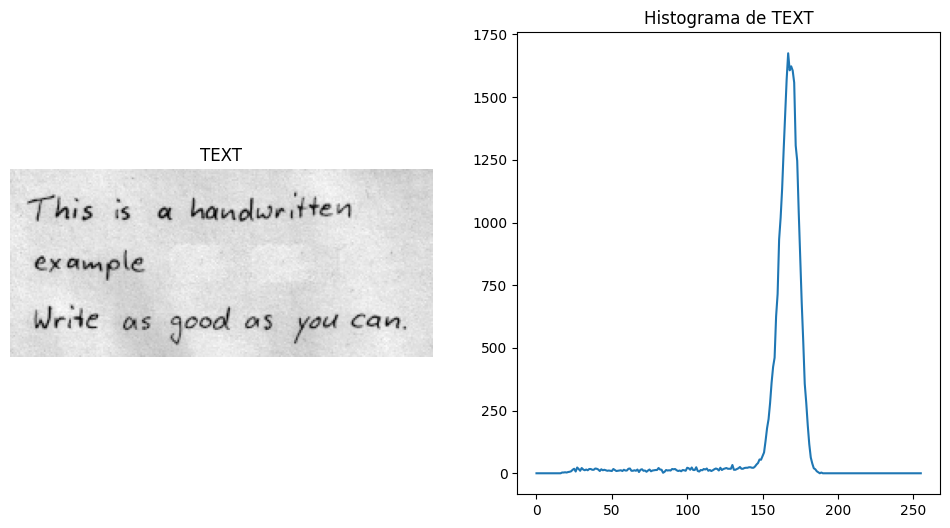

In [12]:
text_image = cv2.imread(images_path + 'TEXT.png', cv2.IMREAD_GRAYSCALE)
hist_text = cv2.calcHist([text_image], [0], None, [256], [0, 256])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(text_image, cmap='gray')
plt.axis('off')
plt.title('TEXT')
plt.subplot(1, 2, 2)
plt.plot(hist_text)
plt.title('Histograma de TEXT')
plt.show()

### **1.9 Introduzca ahora una sombra circular lateral y una sombra sinusoidal en la imagen (pruebe con diferentes valores y úselos para los pasos 10 y 11). Visualice el resultado.**

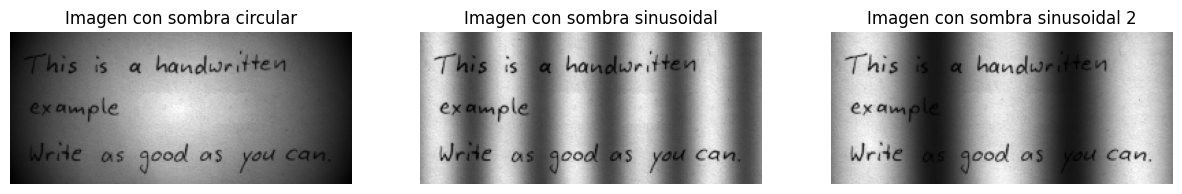

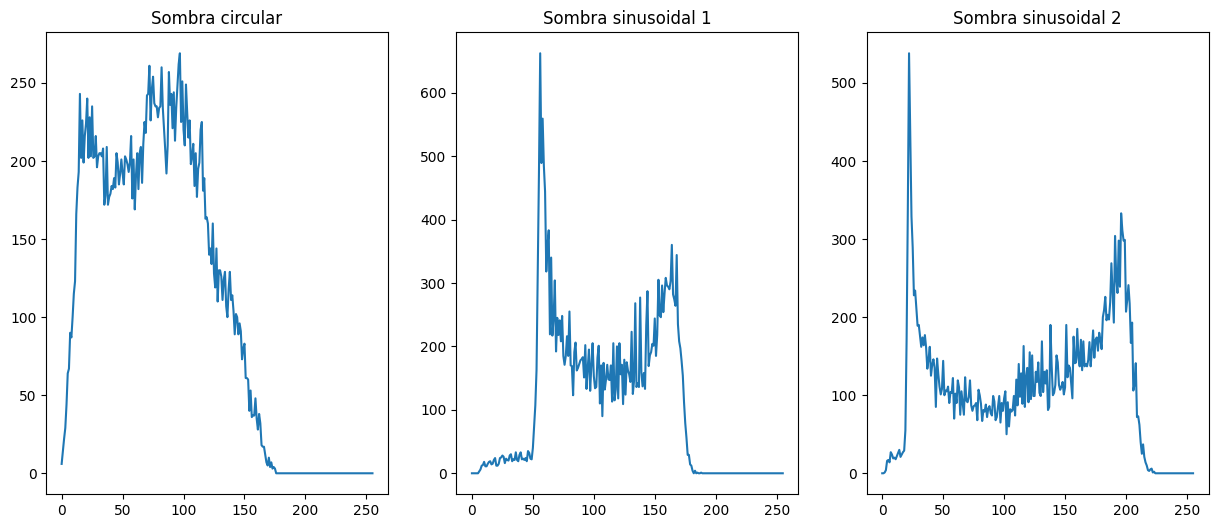

In [13]:
# calculo de la sobra circular
rows, cols = text_image.shape
x, y = np.meshgrid(np.arange(cols), np.arange(rows))
cx, cy = cols // 2, rows // 2  # centro de la imagen
distance = np.sqrt((x - cx) ** 2 + (y - cy) ** 2) # distancia de cada píxel al centro
max_dist = np.sqrt(cx**2 + cy**2) # distancia máxima posible (esquina de la imagen)
spot_shading = 1 - (distance / max_dist)  # aplicar un gradiente
spot_image = text_image * spot_shading
spot_image = spot_image.astype(np.uint8)

# calculo de sombra sinusoidal 1
frequency = 50  # cantidad de perturbaciones
amplitude = 0.5  # intensidad de los picos
sinusoidal_shading = (1 + amplitude * np.sin(2 * np.pi * x / frequency)) / 1.5 # aplicar
sinusoidal_image = text_image * sinusoidal_shading
sinusoidal_image = sinusoidal_image.astype(np.uint8)

# calculo de sombra sinusoidal 2
frequency = 100  # cantidad de perturbaciones
amplitude = 0.8  # intensidad de los picos
sinusoidal_shading2 = (1 + amplitude * np.sin(2 * np.pi * x / frequency)) / 1.5 # aplicar
sinusoidal_image2 = text_image * sinusoidal_shading2
sinusoidal_image2 = sinusoidal_image2.astype(np.uint8)

# visualización de las imágenes con sombras
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.imshow(spot_image, cmap='gray')
plt.axis('off')
plt.title('Imagen con sombra circular')
plt.subplot(1, 3, 2)
plt.imshow(sinusoidal_image, cmap='gray')
plt.axis('off')
plt.title('Imagen con sombra sinusoidal')
plt.subplot(1, 3, 3)
plt.imshow(sinusoidal_image2, cmap='gray')
plt.axis('off')
plt.title('Imagen con sombra sinusoidal 2')
plt.show()

# visualización de los histogramas de las imágenes con sombras
hist_spot = cv2.calcHist([spot_image], [0], None, [256], [0, 256])
hist_sinusoidal = cv2.calcHist([sinusoidal_image], [0], None, [256], [0, 256])
hist_sinusoidal2 = cv2.calcHist([sinusoidal_image2], [0], None, [256], [0, 256])

plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.plot(hist_spot)
plt.title('Sombra circular')
plt.subplot(1, 3, 2)
plt.plot(hist_sinusoidal)
plt.title('Sombra sinusoidal 1')
plt.subplot(1, 3, 3)
plt.plot(hist_sinusoidal2)
plt.title('Sombra sinusoidal 2')
plt.show()

### **1.10 Aplique el algoritmo de umbralización de Otsu sobre la imagen original y las dos modificaciones. ¿Qué sucede? ¿Por qué sucede esto? ¿Qué alternativas puede emplear para mitigar este resultado?**

Valor de umbral para sombra circular: 75.0
Valor de umbral para sombra sinusoidal 1: 108.0
Valor de umbral para sombra sinusoidal 2: 109.0


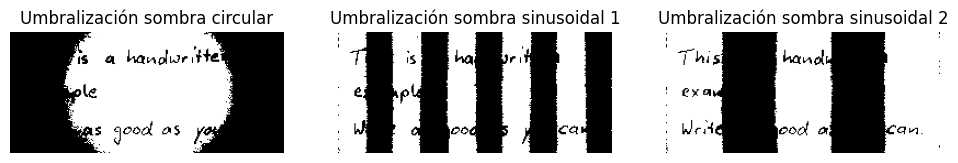

In [14]:
# umbralizaciones manuales con valor 65
thresh1, thres_image_spot = cv2.threshold(spot_image, 65, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
thresh2, thres_image_sinusoidal1 = cv2.threshold(sinusoidal_image, 65, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
thresh3, thres_image_sinusoidal2 = cv2.threshold(sinusoidal_image2, 65, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

print(f"Valor de umbral para sombra circular: {thresh1}")
print(f"Valor de umbral para sombra sinusoidal 1: {thresh2}")
print(f"Valor de umbral para sombra sinusoidal 2: {thresh3}")

# visualización
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(thres_image_spot, cmap='gray')
plt.axis('off')
plt.title('Umbralización sombra circular')
plt.subplot(1, 3, 2)
plt.imshow(thres_image_sinusoidal1, cmap='gray')
plt.axis('off')
plt.title('Umbralización sombra sinusoidal 1')
plt.subplot(1, 3, 3)
plt.imshow(thres_image_sinusoidal2, cmap='gray')
plt.axis('off')
plt.title('Umbralización sombra sinusoidal 2')
plt.show()

La introducción de variaciones de iluminación como sombras de diversas naturalezas altera la distribución de intensidades en el histograma, eliminando la separación clara entre las clases, en este caso texto y fondo. Esto genera un solapamiento en el espectro de gris, donde los píxeles de la sombra adquieren valores de intensidad similares a los del texto. Como el algoritmo de Otsu busca un umbral global que minimice la varianza intra-clase, termina seleccionando un valor que clasifica erróneamente las sombras como parte del texto.

Para mitigar este efecto, se pueden emplear técnicas de preprocesamiento como filtros de suavizado, o la detección previa de contornos para segmentar el texto. Otra alternativa es la umbralización adaptativa, la cual calcula umbrales locales y podría compensar los efectos de la sombra al separar la imagen en regiones.

### **1.11 Aplique ahora un algoritmo de adaptación del umbral en función de las propiedades locales. Compare sus resultados con el algoritmo anterior, usando varios valores para el vecindario local. ¿En qué cambia el resultado con relación al método de Otsu? ¿Qué implicaciones tiene esto? ¿Cómo puede mejorar el resultado de la segmentación para reducir el ruido en ambos casos?**

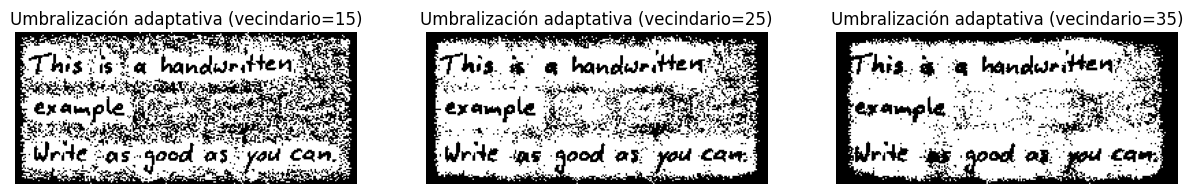

In [ ]:
# aplicar umbralización adaptativa
vecindarios = [15, 25, 35]

umbralizaciones = []
for v in vecindarios:
    ti = threshold_local(spot_image, block_size=v, method='mean') #NOTA: X debe ser impar
    binary_image = spot_image > ti
    thresholded_image = binary_image*255
    umbralizaciones.append(thresholded_image)


plt.figure(figsize=(15, 6))
for i, v in enumerate(vecindarios):
    plt.subplot(1, 3, i+1)
    plt.imshow(umbralizaciones[i], cmap='gray')
    plt.axis('off')
    plt.title(f'Umbralización adaptativa (vecindario={v})')
plt.show()


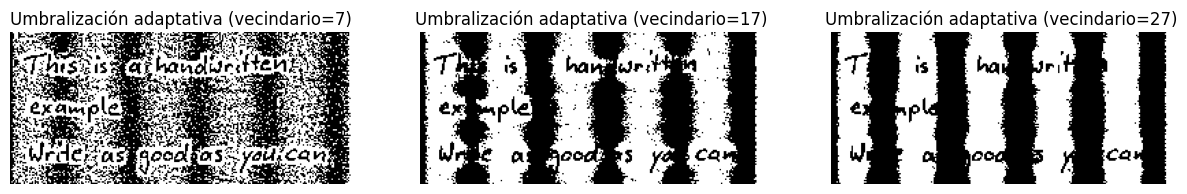

In [25]:
vecindarios = [7, 17, 27]

umbralizaciones = []
for v in vecindarios:
    ti = threshold_local(sinusoidal_image, block_size=v, method='mean') #NOTA: X debe ser impar
    binary_image = sinusoidal_image > ti
    thresholded_image = binary_image*255
    umbralizaciones.append(thresholded_image)


plt.figure(figsize=(15, 6))
for i, v in enumerate(vecindarios):
    plt.subplot(1, 3, i+1)
    plt.imshow(umbralizaciones[i], cmap='gray')
    plt.axis('off')
    plt.title(f'Umbralización adaptativa (vecindario={v})')
plt.show()

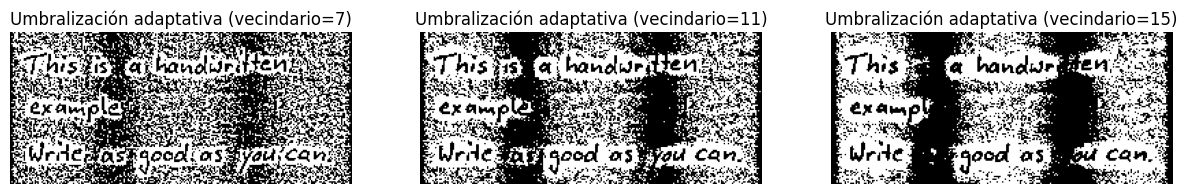

In [30]:
vecindarios = [7, 11, 15]

umbralizaciones = []
for v in vecindarios:
    ti = threshold_local(sinusoidal_image2, block_size=v, method='mean') #NOTA: X debe ser impar
    binary_image = sinusoidal_image2 > ti
    thresholded_image = binary_image*255
    umbralizaciones.append(thresholded_image)


plt.figure(figsize=(15, 6))
for i, v in enumerate(vecindarios):
    plt.subplot(1, 3, i+1)
    plt.imshow(umbralizaciones[i], cmap='gray')
    plt.axis('off')
    plt.title(f'Umbralización adaptativa (vecindario={v})')
plt.show()

El resultado de la umbralización adaptativa difiere del método de Otsu en que este último busca un umbral global para toda la imagen, lo cual resulta insuficiente ante condiciones de iluminación no uniforme. En contraste, la umbralización adaptativa calcula umbrales locales para cada píxel basándose en las propiedades de su vecindario. Esto permite que el algoritmo se adapte a las variaciones de intensidad, como las sombras introducidas, logrando una segmentación más precisa del texto al enfocarse en el contraste local en lugar de la intensidad absoluta de los píxeles. Sin embargo, el resultado de la umbralización adaptativa es altamente sensible al tamaño del vecindario local. Un vecindario muy pequeño logra segmentar el texto en zonas de sombra, pero introduce mucho ruido granular en el fondo. Por el contrario, un vecindario muy grande reduce el ruido al promediar más información, pero pierde su capacidad de adaptación local, tendiendo un comportamiento similar al de Otsu y volviendo a incluir las sombras como parte de la segmentación.

Las implicaciones de esto son que, para imágenes con gradientes de luz complejos, no existe un umbral único ideal. Es necesario ajustar el tamaño del vecindario para equilibrar la precisión de la segmentación y la cantidad de ruido introducido. Además, es importante tener en cuenta que la umbralización adaptativa puede ser computacionalmente más costosa que el método de Otsu, especialmente para vecindarios grandes.

Para mejorar el resultado y reducir el ruido en ambos casos, se pueden emplear filtros previos para eliminar variaciones de intensidad irrelevantes, o aplicar operaciones posteriores a la segmentación que consigan eliminar ruido, como la eliminación de puntos aislados.

---


Cree una nueva sección en su notebook.

Cargue la imagen de trabajo y visualícela.

Manualmente, usando paint, cree una máscara asociada al área oscura que corresponde a los pulmones, tratando de respetar la región de la manera más precisa posible.

Usando ahora dos semillas, utilice el algoritmo de crecimiento de regiones para segmentar de forma automática el área de los pulmones. Pruebe con varios valores de tolerancia.

Compare ambos resultados. ¿Cómo se puede determinar cualitativamente dos regiones? ¿Cuál segmentación tiene mejor calidad?

Investigue el coeficiente de Sorensen-Dice. Esta es una medida de la similitud entre dos áreas segmentadas. Aplíquelo sobre las segmentaciones del punto 3 y 4. ¿Cómo puede interpretar el resultado? ¿Respalda el análisis cualitativo el valor obtenido?

Guarde los cambios en su notebook.

# **2. Segmentación por crecimiento de regiones**

### **2.1 Cree una nueva sección en su notebook**
### **2.2 Cargue la imagen de trabajo y visualícela**

(247, 250)


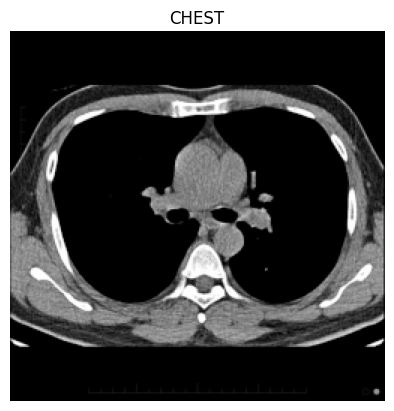

In [45]:
chest_image = cv2.imread(images_path + 'CHEST.png', cv2.IMREAD_GRAYSCALE)
print(chest_image.shape)

plt.imshow(chest_image, cmap='gray')
plt.axis('off')
plt.title('CHEST')
plt.show()

### **2.3 Manualmente, usando paint, cree una máscara asociada al área oscura que correponde a los pulmones, tratando de respetar la región de la manera más precisa posible.**

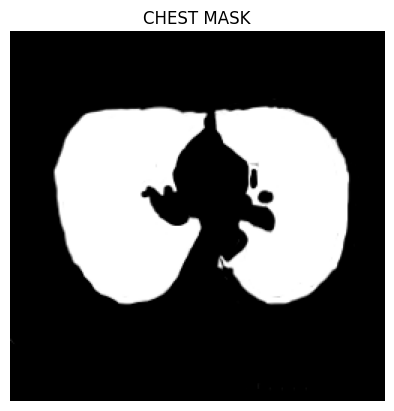

In [64]:
chest_mask_manual = cv2.imread(images_path + 'CHEST_MASK.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(chest_mask_manual, cmap='gray')
plt.axis('off')
plt.title('CHEST MASK')
plt.show()

### **2.4 Usando ahora dos semillas, utilice el algoritmo de crecimiento de regiones para segmentar de forma automática el área de los pulmones. Pruebe con varios valores de tolerancia.**

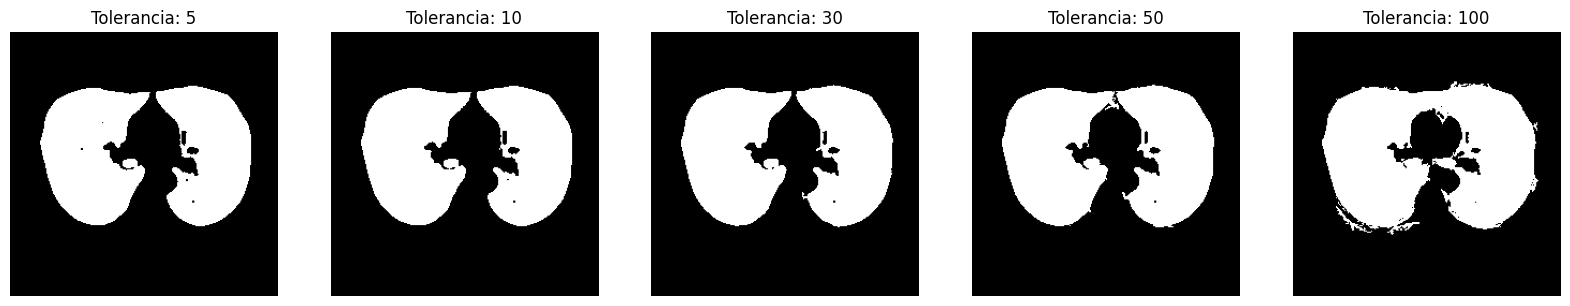

In [77]:
# seleccionar semillas
semilla1 = (70, 70) # region del pulmón izquierdo
semilla2 = (70, 160) # region del pulmón derecho

# variació de intensidad permitida
tolerancias = [5, 10, 30, 50, 100]

results = []
for tol in tolerancias:
    chest_mask_left = flood(chest_image, semilla1, tolerance=tol)
    chest_mask_right = flood(chest_image, semilla2, tolerance=tol)
    chest_mask = chest_mask_left | chest_mask_right
    results.append(chest_mask)

plt.figure(figsize=(20, 4))
for i, tol in enumerate(tolerancias):
    plt.subplot(1, 5, i+1)
    plt.imshow(results[i], cmap='gray')
    plt.axis('off')
    plt.title(f'Tolerancia: {tol}')

Para obtener la segmentación de los pulmones, se seleccionaron manualmente dos semillas correspondientes a cada pulmón. Luego se aplicó el algoritmo de crecimiento de regiones, expandiendose a partir de las semillas seleccionada y utilizando diferentes valores de tolerancia para controlar la expansión.

### **2.5 Compare ambos resultados. ¿Cómo se puede determinar cualitativamente dos regiones? ¿Cuál segmentación tiene mejor calidad?**

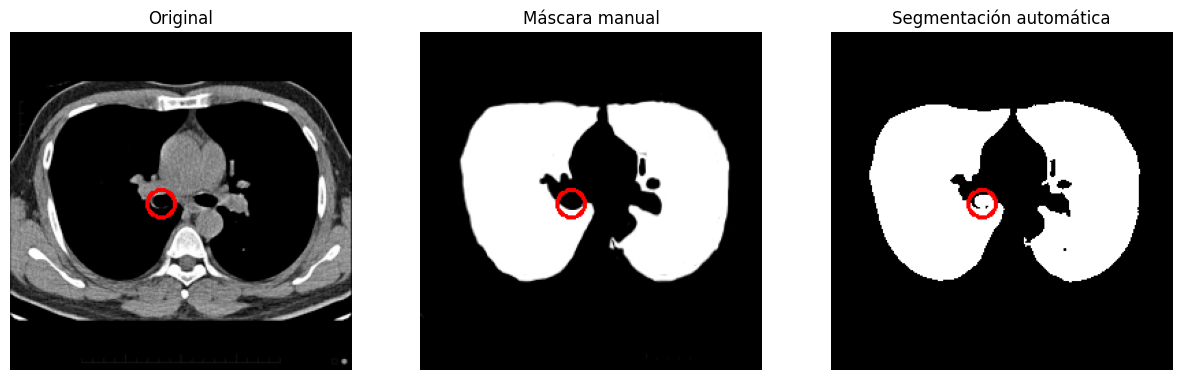

In [91]:
# dibujar un círculo en la posición con error
centro = (110, 125) 
radio = 10  
color = (255, 0, 0) # color rojo
grosor = 2

# leer las imagenes a color
img_1 = cv2.cvtColor(chest_image, cv2.COLOR_GRAY2RGB)
img_2 = cv2.cvtColor(chest_mask_manual, cv2.COLOR_GRAY2RGB)
seg_data = (results[2] * 255).astype('uint8')
img_3 = cv2.cvtColor(seg_data, cv2.COLOR_GRAY2RGB)

# dibujar el círculo rojo
cv2.circle(img_1, centro, radio, color, grosor)
cv2.circle(img_2, centro, radio, color, grosor)
cv2.circle(img_3, centro, radio, color, grosor)

# visualizar
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_1) 
plt.axis('off')
plt.title('Original')

plt.subplot(1, 3, 2)
plt.imshow(img_2)
plt.axis('off')
plt.title('Máscara manual')

plt.subplot(1, 3, 3)
plt.imshow(img_3) 
plt.axis('off')
plt.title('Segmentación automática')

plt.show()

### **2.5 Compare ambos resultados. ¿Cómo se puede determinar cualitativamente dos regiones? ¿Cuál segmentación tiene mejor calidad?**

Comparando los resultados de ambas segmentaciones (manual y automática con tolerancia 30, el mejor resultado de las automáticas), se observa que la máscara manual presenta una segmentación más completa en cuanto a la anatomía general, pues hay un área de la imagen que el algoritmo de crecimiento de regiones no logró excluir correctamente debido a variaciones en los niveles de gris con ninguno de los niveles de tolerancia. Esta área está delimitada en las imágenes previas con un círculo rojo. Sin embargo, en términos de detalle local, la segmentación automática logra respetar de mejor manera las fronteras sinuosas de los pulmones.Con esto en mente, la segmentación manual tiene una mejor calidad en términos de cobertura general, mientras que la segmentación automática tiene una mejor calidad en términos de precisión local.

Para determinar cualitativamente la calidad de las segmentaciones se puede realizar una inspección superponiendo cada máscara sobre la imagen, de manera que se pueda verificar la coincidencia entre las estructuras, o simplemente comparando visualmente cada máscara con la imagen original en caso que haya diferencias significativas entre ambas, como es este caso.


### **2.6 Investigue el coeficiente de Sorensen-Dice. Esta es una medida de la similitud entre dos áreas segmentadas. Aplíquelo sobre las segmentaciones del punto 3 y 4. ¿Cómo puede interpretar el resultado? ¿Respalda el análisis cualitativo el valor obtenido?**

In [90]:
def sorensen_dice_coefficient(mask1, mask2):
    intersection = (mask1 & mask2).sum()
    size_mask1 = mask1.sum()
    size_mask2 = mask2.sum()
    return (2.0 * intersection) / (size_mask1 + size_mask2)

chest_mask_manual_binary = chest_mask_manual > 0 # había tonalidades de gris
for i, result in enumerate(results):
    print(f"Sorensen-Dice coefficient, tolerance {tolerancias[i]}: {sorensen_dice_coefficient(result, chest_mask_manual_binary):.4f}")

Sorensen-Dice coefficient, tolerance 5: 0.9445
Sorensen-Dice coefficient, tolerance 10: 0.9468
Sorensen-Dice coefficient, tolerance 30: 0.9516
Sorensen-Dice coefficient, tolerance 50: 0.9532
Sorensen-Dice coefficient, tolerance 100: 0.9388


El coeficiente de Sorensen-Dice es una métrica que cuantifica la similitud entre dos conjuntos. Se calcula como el doble del tamaño de la intersección de los conjuntos dividido por la suma de sus tamaños. En el contexto de segmentación, un valor de 1 indica una coincidencia perfecta entre las dos segmentaciones, mientras que un valor de 0 indica que no hay superposición, por lo que se implementa dicha intersección haciendo una operación lógica AND entre las máscaras binarias de ambas segmentaciones.

Comparando los resultados cualitativos discutidos anteriormente, notamos que entre todas las tolerancias y la segmentación manual hay pequeñas discrepancias en las áreas seleccionadas, probablemente guiada por el área incluida en la máscara manual pero excluida en la máscara automática indicada en el punto 2.5. Las más cercanas a la manual son las segmentaciones automáticas con tolerancia 50 y 30, sin embargo, si nos guiaramos solo por este valor no notaríamos que en la máscara 50 hay una área incluida de más que no corresponde a los pulmones. Por lo tanto, aunque el coeficiente es una herramienta útil para cuantificar la similitud y respalda en su mayoría el análisis cualitativo, es importante no depender exclusicamente de esta métrica.

---

# 3. Segmentación por agrupación


### **3.1 Cree una nueva sección en su notebook.**
### **3.2 Cargue la imagen de trabajo y visualícela.**

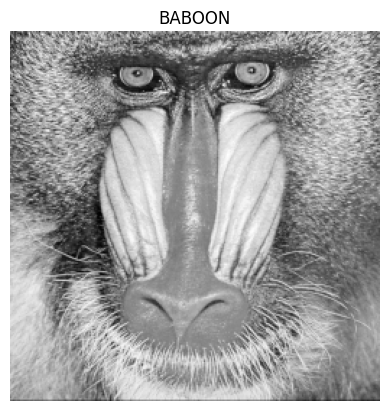

In [110]:
baboon_image = cv2.imread(images_path + 'BABOON.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(baboon_image, cmap='gray')
plt.axis('off')
plt.title('BABOON')
plt.show()


### **3.3 Aplique el algoritmo de K-means para segmentar por agrupación. Utilice un valor de K=3. Visualice los resultados.**


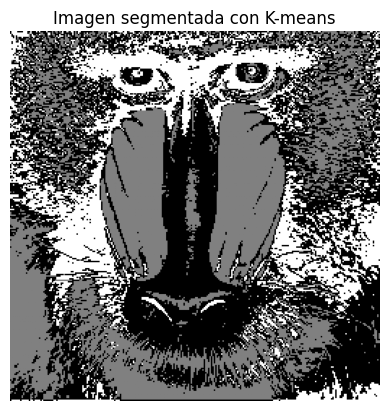

In [111]:
# obtener dimensiones de la imagen
N, M = baboon_image.shape

# definir número de clusters
num_clusters = 3

# aplicar K-means
img_flat = baboon_image.reshape(N*M,1)
model_kmeans = KMeans(n_clusters=num_clusters)
model_kmeans.fit(img_flat)
segmented_image = model_kmeans.labels_.reshape(N,M,1)

# visualizar la imagen segmentada
plt.imshow(segmented_image, cmap='gray')
plt.axis('off')
plt.title('Imagen segmentada con K-means')
plt.show()

### **3.4 Utilice el método del codo para encontrar el valor óptimo de grupos en la imagen. Visualice los resultados ¿Cómo cambia la segmentación?**

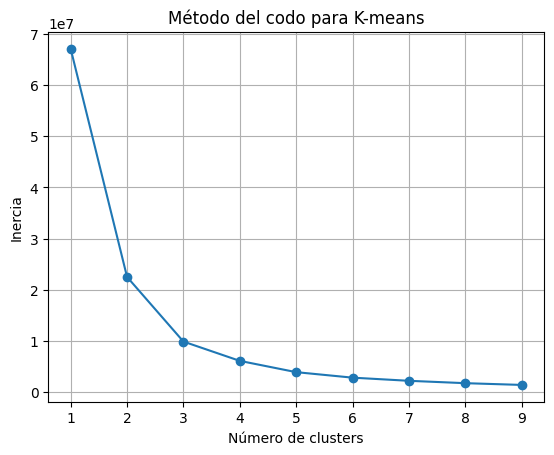

In [108]:
# metodo del codo obteniendo la inercia para diferentes nums de clusters
cluster_range = range(1, 10)

inertia_values = []
for k in cluster_range:
    model = KMeans(n_clusters=k)
    model.fit(img_flat)
    inertia_values.append(model.inertia_)

plt.plot(cluster_range, inertia_values, marker='o')
plt.title('Método del codo para K-means')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.xticks(cluster_range)
plt.grid()
plt.show()

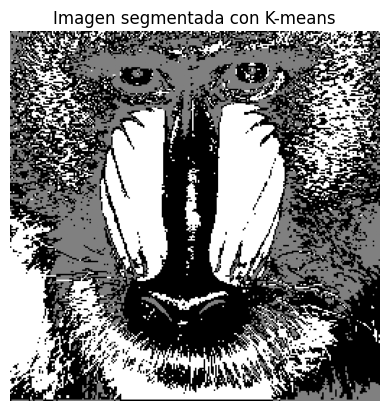

In [131]:
# obtener dimensiones de la imagen
N, M = baboon_image.shape

# definir número de clusters
num_clusters_optimal = 3

# aplicar K-means
img_flat = baboon_image.reshape(N*M,1)
model_kmeans = KMeans(n_clusters=num_clusters_optimal)
model_kmeans.fit(img_flat)
segmented_image = model_kmeans.labels_.reshape(N,M,1)

# visualizar la imagen segmentada
plt.imshow(segmented_image, cmap='gray')
plt.axis('off')
plt.title('Imagen segmentada con K-means')
plt.show()

FALTA EXPLICAR


### **3.5 Aplique el algoritmo de súperpixeles SLIC. Utilice un valor de K=25. Visualice los resultados. ¿Cuántos súperpixeles se encontraron?**

Número de súperpixeles: 12


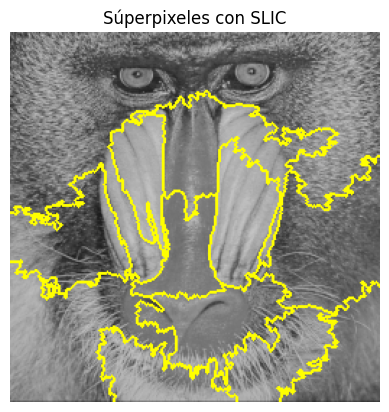

In [132]:
segments = slic(cv2.merge([baboon_image, baboon_image, baboon_image]), n_segments=25)
print(f"Número de súperpixeles: {len(np.unique(segments))}")

#Visualización de los súperpixeles superpuestos en la imagen
plt.imshow(segmentation.mark_boundaries(baboon_image, segments))
plt.axis('off')
plt.title('Súperpixeles con SLIC')
plt.show()


FALTA EXPLICAR

### **3.6 Aplique el algoritmo de súperpixeles usando el valor óptimo de grupos calculado en el paso 4. Utilice dicho multiplicado por 4 y por 10. Visualice los resultados ¿Qué puede observar? ¿Qué diferencias hay entre las imágenes generadas?**

Número de súperpixeles (4x): 4
Número de súperpixeles (10x): 14


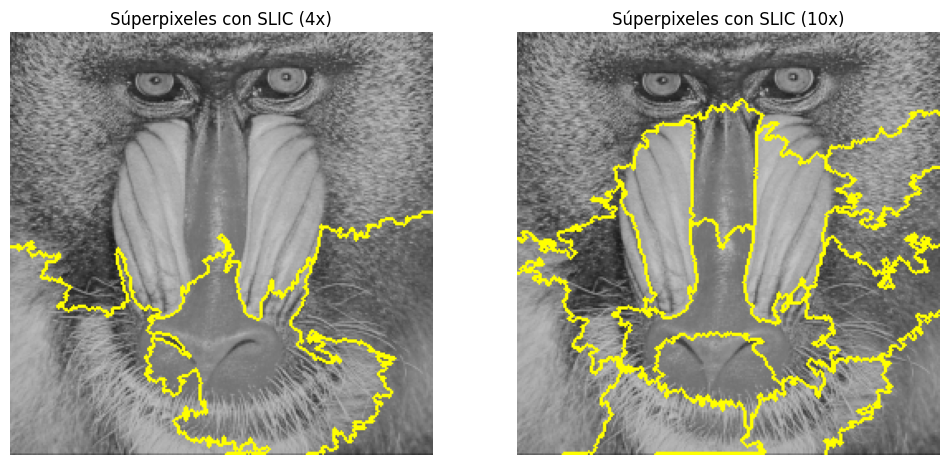

In [133]:
segments_by4 = slic(cv2.merge([baboon_image, baboon_image, baboon_image]), n_segments=num_clusters_optimal*4)
segments_by10 = slic(cv2.merge([baboon_image, baboon_image, baboon_image]), n_segments=num_clusters_optimal*10)

print(f"Número de súperpixeles (4x): {len(np.unique(segments_by4))}")
print(f"Número de súperpixeles (10x): {len(np.unique(segments_by10))}")

#Visualización de los súperpixeles superpuestos en la imagen
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(segmentation.mark_boundaries(baboon_image, segments_by4))
plt.axis('off')
plt.title('Súperpixeles con SLIC (4x)')

plt.subplot(1, 2, 2)
plt.imshow(segmentation.mark_boundaries(baboon_image, segments_by10))
plt.axis('off')
plt.title('Súperpixeles con SLIC (10x)')
plt.show()


### **3.7 ¿Cuál es la diferencia entre las dos técnicas de segmentación por agrupación utilizadas? ¿Cuál presenta el mejor resultado?  ¿Conclusión?**